In [29]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/subho117/rainfall-prediction-using-machine-learning/Rainfall.csv


In [70]:
# Importing pickle library
# Used for saving and loading trained machine learning models

import pickle


# Importing pandas library
# Used for data loading, manipulation, and analysis

import pandas as pd


# Importing NumPy library
# Used for numerical computations and array operations

import numpy as np


# Importing matplotlib.pyplot
# Used for plotting graphs and visualizations

import matplotlib.pyplot as plt


# Importing seaborn library
# Used for statistical data visualization

import seaborn as sns


# Importing resample
# Used for upsampling/downsampling data
# Helpful for handling imbalanced datasets

from sklearn.utils import resample


# Importing train_test_split
# Used to split dataset into training and testing data

# Importing GridSearchCV
# Used for hyperparameter tuning

# Importing cross_val_score
# Used to evaluate model performance using cross-validation

from sklearn.model_selection import (
    
    train_test_split,
    
    GridSearchCV,
    
    cross_val_score
)


# Importing RandomForestClassifier
# Ensemble machine learning algorithm used for classification

from sklearn.ensemble import RandomForestClassifier


# Importing evaluation metrics

# accuracy_score -> calculates model accuracy

# confusion_matrix -> shows prediction comparison matrix

# classification_report -> provides precision, recall, f1-score

from sklearn.metrics import (
    
    accuracy_score,
    
    confusion_matrix,
    
    classification_report
)


# Importing preprocessing tools

# LabelEncoder -> converts categorical labels into numerical values

# StandardScaler -> standardizes/scales feature values
# (usually not required for Random Forest)

from sklearn.preprocessing import (
    
    LabelEncoder,
    
    StandardScaler
)


# Confirmation message after successful imports

print("The libraries are imported successfully!!!!")

The libraries are imported sucessfully!!!!1


In [31]:
# Loading the rainfall dataset from the CSV file using pandas

dataset = pd.read_csv(
    "/kaggle/input/datasets/subho117/rainfall-prediction-using-machine-learning/Rainfall.csv"
)

# Displaying the first 5 rows of the dataset
# Helps understand:
# - column names
# - dataset structure
# - feature values
# - sample records

dataset.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [32]:
# Displaying complete information about the dataset

# info() provides:
# - total number of rows and columns
# - column names
# - datatype of each column
# - non-null value counts
# - memory usage

# Helpful for:
# - understanding dataset structure
# - identifying missing values
# - checking datatypes before preprocessing

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [33]:
# Removing unwanted spaces from column names

# .str.strip() removes:
# - leading spaces
# - trailing spaces
#
# Helpful because extra spaces in column names
# can cause errors while accessing columns

dataset.columns = dataset.columns.str.strip()

# Displaying cleaned column names

dataset.columns

Index(['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection',
       'windspeed'],
      dtype='object')

In [34]:
# Checking the number of missing/null values in each column

# isnull() -> identifies missing values
# sum() -> counts total missing values column-wise

# Helpful for:
# - detecting incomplete data
# - deciding preprocessing steps
# - handling missing values before model training

dataset.isnull().sum()

day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    1
windspeed        1
dtype: int64

In [36]:
# Handling missing values in the 'winddirection' column

# mode()[0] returns the most frequently occurring value
# Useful for filling missing values in categorical columns

dataset['winddirection'] = dataset['winddirection'].fillna(
    
    dataset['winddirection'].mode()[0]
)


# Handling missing values in the 'windspeed' column

# median() returns the middle value of the column
# Median is preferred for numerical data because
# it is less affected by outliers

dataset['windspeed'] = dataset['windspeed'].fillna(
    
    dataset['windspeed'].median()
)


# Confirmation message after handling missing values

print("Handled the missing values")

Handled the missing values


In [37]:
# Generating statistical summary of numerical columns in the dataset

# describe() provides important statistical information such as:
#
# count -> total non-null values
# mean  -> average value
# std   -> standard deviation (spread of data)
# min   -> minimum value
# 25%   -> first quartile
# 50%   -> median value
# 75%   -> third quartile
# max   -> maximum value

# Helpful for:
# - understanding data distribution
# - detecting outliers
# - analyzing feature ranges
# - identifying abnormal values

dataset.describe()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,15.756831,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,4.419399,101.284153,21.534153
std,8.823592,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,3.934398,81.722827,10.056054
min,1.000000,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,10.000000,4.400000
25%,8.000000,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.500000,40.000000,13.725000
50%,16.000000,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,3.500000,70.000000,20.500000
75%,23.000000,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,8.200000,190.000000,27.825000
max,31.000000,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,12.100000,350.000000,59.500000


In [38]:
# Removing the 'day' column from the dataset

# axis=1 indicates column-wise removal

# The 'day' column is removed because:
# - it may not contribute useful information for prediction
# - it can act as unnecessary/noisy data
# - removing irrelevant features can improve model performance

dataset = dataset.drop(
    
    columns='day',
    
    axis=1
)

# Confirmation message after removing the column

print("Removed the day column")

removed the days column


In [39]:
# Creating an object of LabelEncoder
# Used to convert categorical text labels into numerical values

encoder = LabelEncoder()


# Encoding the 'rainfall' column
#
# Converts categorical values such as:
# 'yes' -> 1
# 'no'  -> 0
#
# Machine learning models require numerical data,
# so encoding categorical labels is necessary

dataset['rainfall'] = encoder.fit_transform(
    
    dataset['rainfall']
)


# Confirmation message after encoding

print("Replaced yes/no values with numerical values")

Replaced the yes/no to numerical values


In [40]:
# Getting the shape of the dataset

# dataset.shape returns:
# (number_of_rows, number_of_columns)

rows, cols = dataset.shape

# Displaying total number of rows

print("The rows =", rows)

# Displaying total number of columns

print("The cols =", cols)

The rows = 366
The cols = 11


In [44]:
# Setting the default style for seaborn visualizations

# 'whitegrid' adds:
# - white background
# - grid lines for better readability

# Helps create cleaner and more professional-looking plots

sns.set(style='whitegrid')

ValueError: num must be an integer with 1 <= num <= 9, not 10

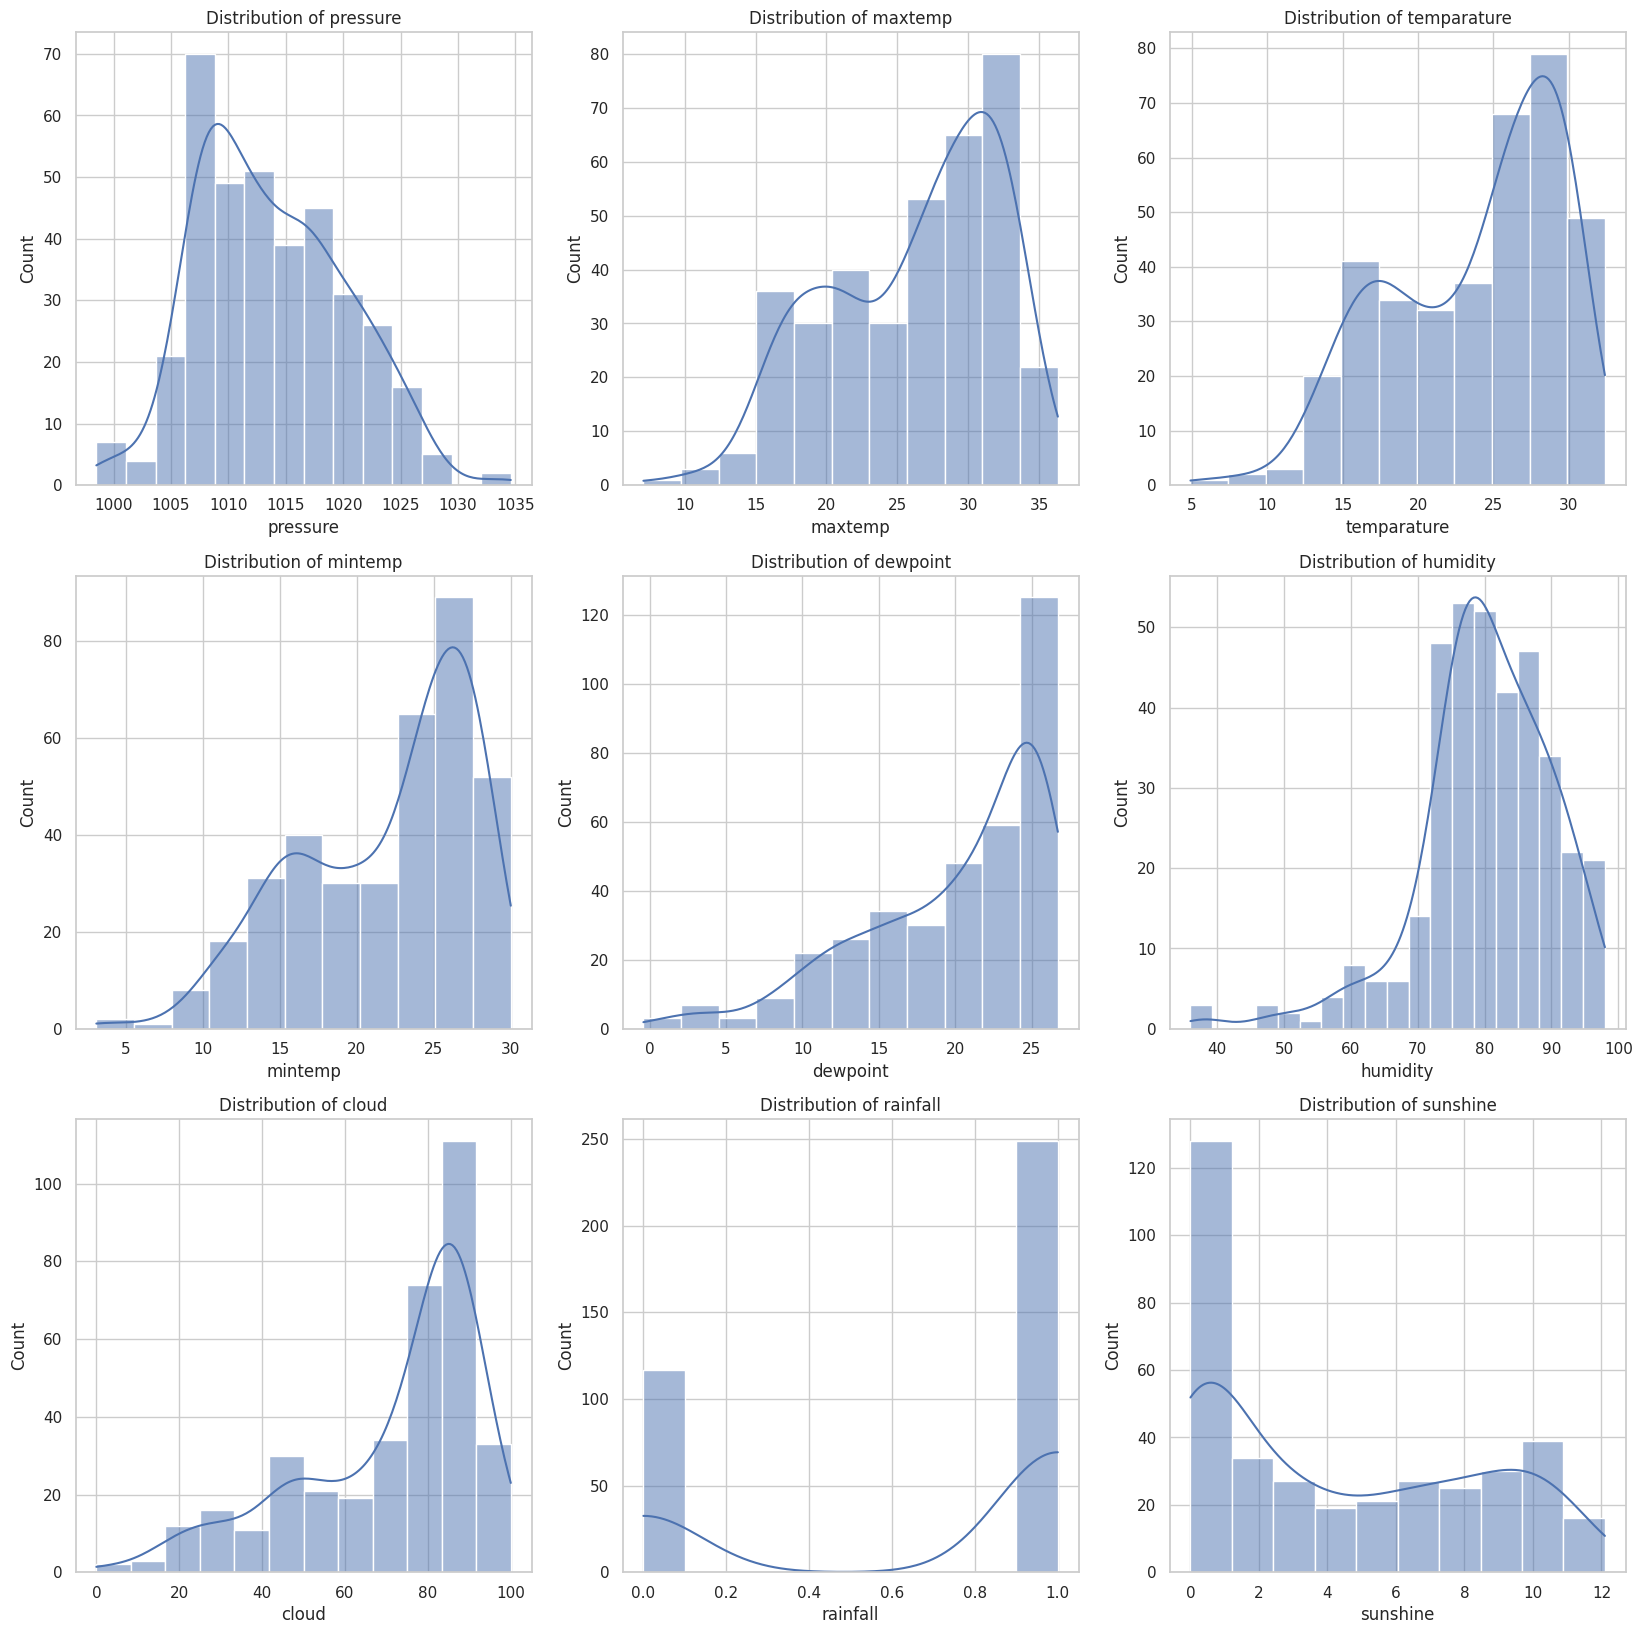

In [46]:
# Creating histograms to visualize data distribution
# for important numerical columns

# Setting figure size for better visualization

plt.figure(figsize=(20,20))


# Creating histogram plots for each numerical feature

for i, column in enumerate(
    
    [
        'pressure',
        'maxtemp',
        'temparature',
        'mintemp',
        'dewpoint',
        'humidity',
        'cloud',
        'rainfall',
        'sunshine',
        'windspeed'
    ],
    
    1
):

    # Creating subplot grid
    #
    # subplot(4,3,i) means:
    # 4 rows
    # 3 columns
    # i -> current plot position
    
    plt.subplot(4, 3, i)

    
    # Creating histogram
    #
    # kde=True adds a smooth density curve
    # to better understand data distribution
    
    sns.histplot(
        
        dataset[column],
        
        kde=True
    )

    
    # Adding title for each plot
    
    plt.title(f"Distribution of {column}")


# Automatically adjusts spacing between plots

plt.tight_layout()


# Displaying all plots

plt.show()

ValueError: num must be an integer with 1 <= num <= 9, not 10

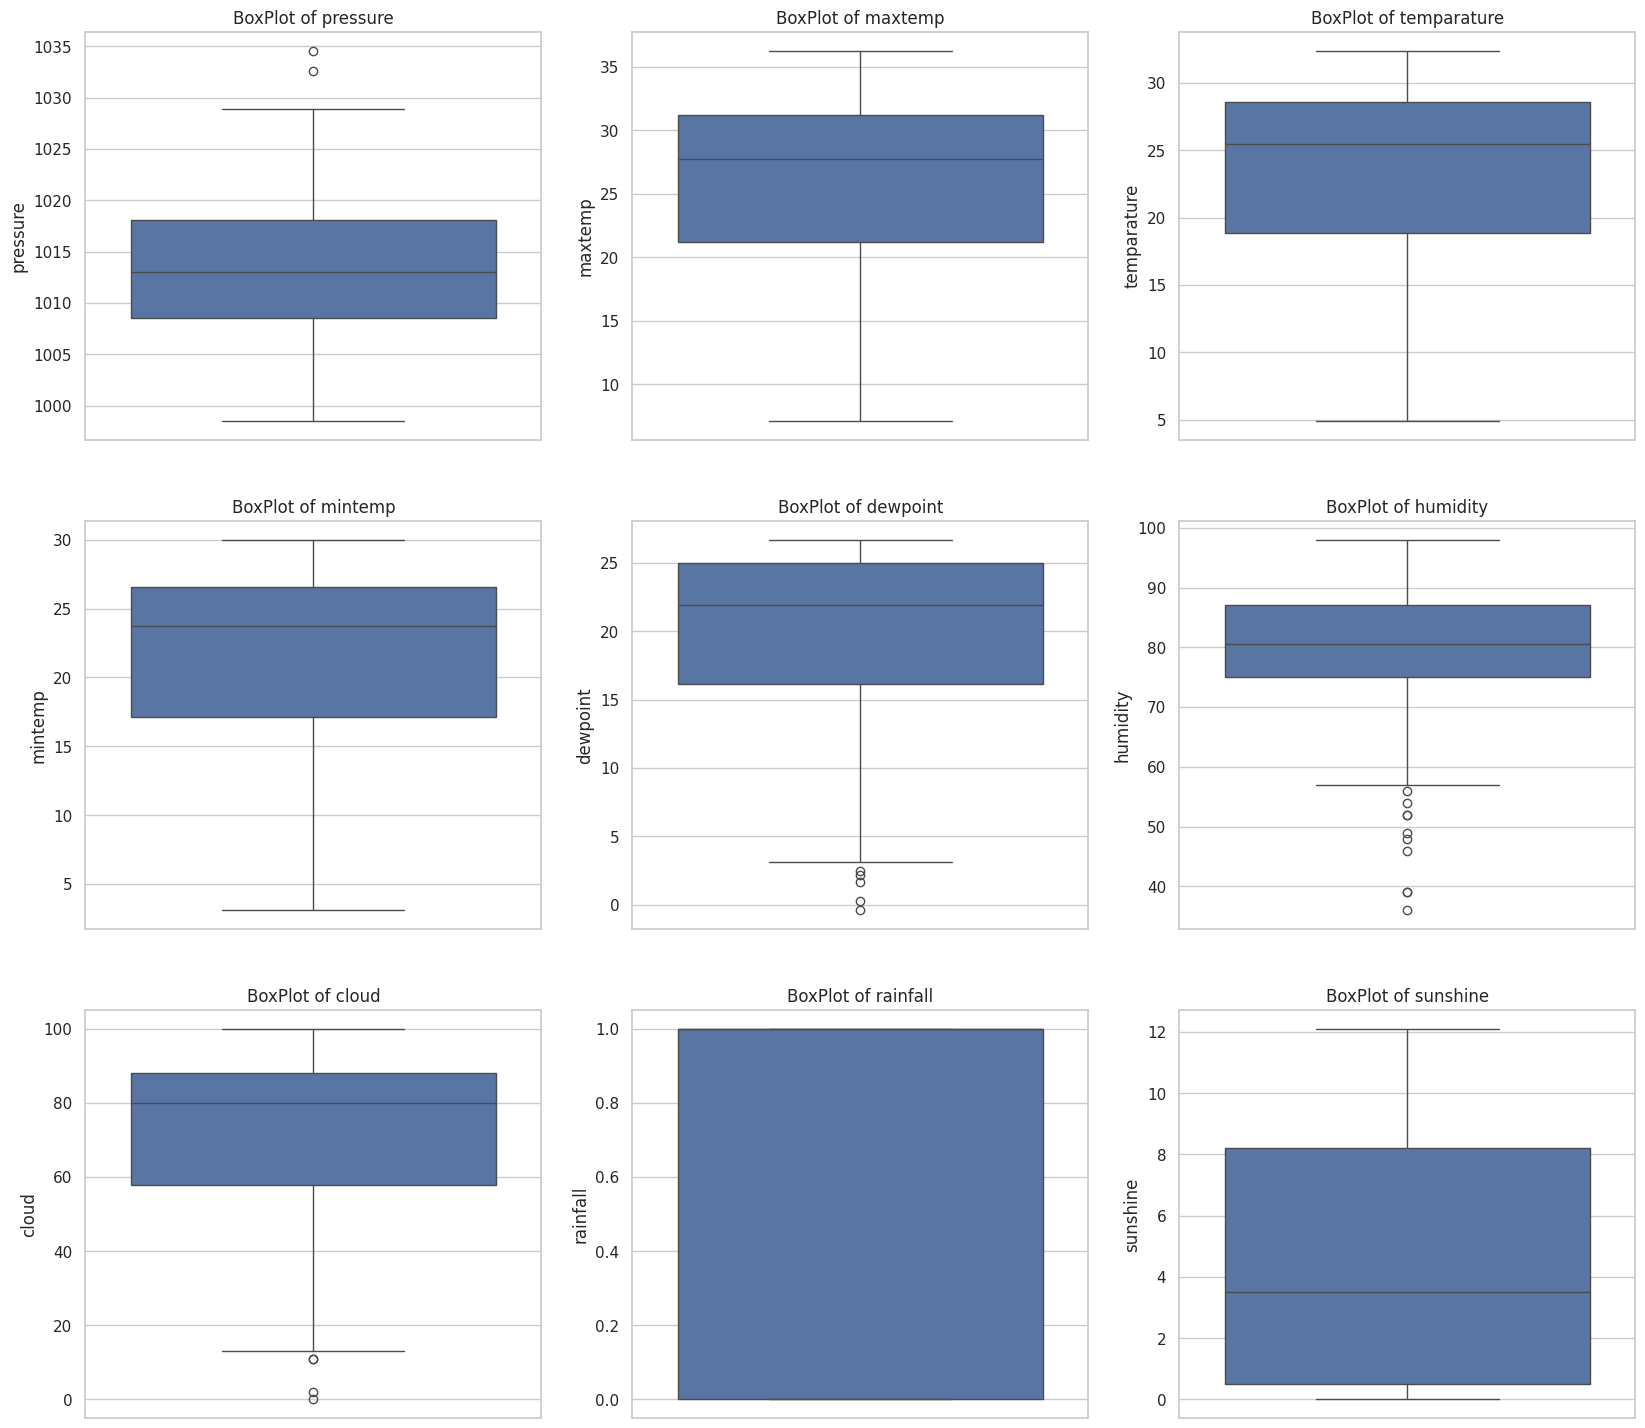

In [47]:
# Creating boxplots to detect outliers
# and understand feature spread/distribution

# Setting figure size for better visualization

plt.figure(figsize=(20,18))


# Creating boxplots for important numerical columns

for i, column in enumerate(
    
    [
        'pressure',
        'maxtemp',
        'temparature',
        'mintemp',
        'dewpoint',
        'humidity',
        'cloud',
        'rainfall',
        'sunshine',
        'windspeed'
    ],
    
    1
):

    # Creating subplot grid
    #
    # subplot(4,3,i) means:
    # 4 rows
    # 3 columns
    # i -> current plot position
    
    plt.subplot(4, 3, i)

    
    # Creating boxplot
    #
    # Boxplots help identify:
    # - median
    # - quartiles
    # - spread of data
    # - outliers
    
    sns.boxplot(
        
        x=dataset[column]
    )

    
    # Adding title for each boxplot
    
    plt.title(f"BoxPlot of {column}")


# Automatically adjusts spacing between plots

plt.tight_layout()


# Displaying all boxplots

plt.show()

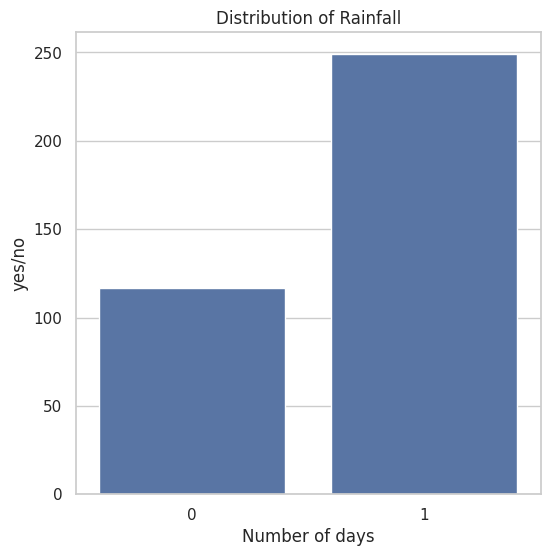

In [48]:
# Creating a countplot to visualize rainfall distribution

# Setting figure size

plt.figure(figsize=(6,6))


# Creating countplot
#
# x='rainfall'
# Displays counts of rainfall categories
#
# data=dataset
# Specifies the dataset to use

sns.countplot(
    
    x='rainfall',
    
    data=dataset
)


# Adding title to the graph

plt.title("Distribution of Rainfall")


# Label for x-axis
# Represents rainfall categories:
# 0 -> No rainfall
# 1 -> Rainfall

plt.xlabel("Rainfall")


# Label for y-axis
# Represents number of records/days

plt.ylabel("Number of Days")


# Displaying the plot

plt.show()

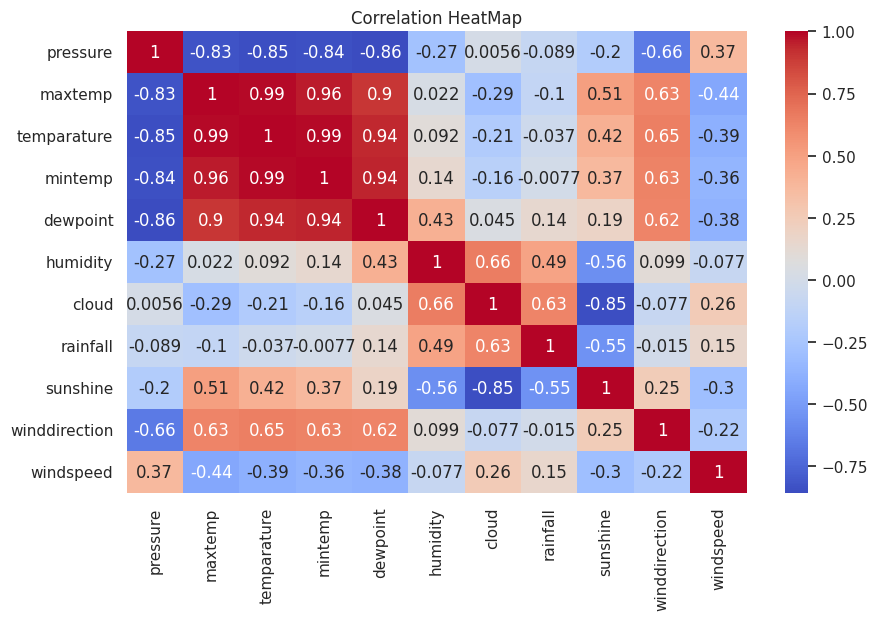

In [49]:
# Creating a heatmap to visualize correlation
# between numerical features in the dataset

# Setting figure size for better readability

plt.figure(figsize=(10,6))


# Creating correlation heatmap

sns.heatmap(
    
    dataset.corr(),
    
    annot=True,
    # Displays correlation values inside the boxes
    
    cmap='coolwarm'
    # Defines color theme for correlation values
)


# Adding title to the heatmap

plt.title("Correlation HeatMap")


# Displaying the heatmap

plt.show()

In [50]:
# Removing highly correlated temperature-related features
# to reduce multicollinearity

# Multicollinearity occurs when multiple features
# are strongly correlated with each other
#
# This can:
# - create redundant information
# - increase model complexity
# - negatively affect some machine learning models

# Removing:
# - mintemp
# - maxtemp
# - temparature

dataset = dataset.drop(
    
    columns=[
        'mintemp',
        'maxtemp',
        'temparature'
    ]
)


# Displaying first 5 rows after feature removal

dataset.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,19.9,95,81,1,0.0,40.0,13.7


In [51]:
# Displaying the number of samples in each rainfall class

# value_counts() counts occurrences of each category
#
# Helpful for checking:
# - class distribution
# - class imbalance
#
# Example:
# 0 -> No rainfall
# 1 -> Rainfall

print(dataset['rainfall'].value_counts())


# If one class has significantly more samples than the other,
# the dataset is considered imbalanced.
#
# Class imbalance can cause the model to become biased
# toward the majority class.

rainfall
1    249
0    117
Name: count, dtype: int64


In [52]:
# Separating majority and minority classes
# from the rainfall target column

# Majority class:
# rainfall = 1
#
# Selecting all rows where rainfall is present

maj = dataset[
    
    dataset['rainfall'] == 1
]


# Minority class:
# rainfall = 0
#
# Selecting all rows where rainfall is absent

mino = dataset[
    
    dataset['rainfall'] == 0
]


# Displaying shapes of both classes
#
# Helps understand class imbalance

print(maj.shape)

print(mino.shape)

(249, 8)
(117, 8)


In [53]:
# Performing downsampling on the majority class
# to handle class imbalance

# resample() randomly selects samples from the majority class

downsampled_maj = resample(
    
    maj,

    
    # replace=False
    # Prevents duplicate sampling
    # Each row is selected only once
    
    replace=False,

    
    # n_samples=len(mino)
    # Reduces majority class size
    # to match minority class size
    
    n_samples=len(mino),

    
    # random_state=123
    # Ensures reproducible/randomly consistent results
    
    random_state=123
)


# Displaying shape of downsampled majority class

print(downsampled_maj.shape)

(117, 8)


In [54]:
# Combining the downsampled majority class
# and minority class into a single balanced dataset

# pd.concat() merges both datasets row-wise

dataset_downsampled = pd.concat(
    
    [
        downsampled_maj,
        
        mino
    ]
)


# Displaying shape of the balanced dataset
#
# Helps verify whether both classes
# were combined successfully

print(dataset_downsampled.shape)

(234, 8)


In [55]:
# Shuffling the balanced dataset randomly

# Why shuffle?
#
# After concatenation:
# - majority class samples may appear together
# - minority class samples may appear together
#
# If data remains ordered,
# the model may learn unwanted patterns from row order

dataset_downsampled = dataset_downsampled.sample(
    
    frac=1,
    # frac=1 means shuffle all rows
    
    random_state=123
    # Ensures reproducible shuffling
).reset_index(
    
    drop=True
    # Resets row indices after shuffling
)


# Displaying first 5 rows of shuffled dataset

dataset_downsampled.head()


# Displaying shape of shuffled dataset

dataset_downsampled.shape

(234, 8)

In [56]:
# Splitting the balanced dataset into:
# - features (input data)
# - target (output label)

# x contains input features used for prediction

x = dataset_downsampled.drop(
    
    columns='rainfall',
    
    axis=1
)

# Removing 'rainfall' because:
# - it is the target/output variable
# - the model should predict this column


# y contains target labels
#
# 0 -> No rainfall
# 1 -> Rainfall

y = dataset_downsampled['rainfall']


# Displaying shape of feature dataset
#
# (rows, columns)

print(x.shape)


# Displaying shape of target column

print(y.shape)

(234, 7)
(234,)


In [77]:
# Splitting the balanced dataset into:
# - training data
# - testing data

# x -> input features
# y -> target labels

x_train, x_test, y_train, y_test = train_test_split(
    
    x,
    y,

    
    # test_size=0.2
    # 20% data used for testing
    # 80% data used for training
    
    test_size=0.2,

    
    # random_state=123
    # Ensures reproducible/randomly consistent splitting
    
    random_state=123
)


# Displaying shapes of training and testing datasets

print("x_train shape :", x_train.shape)

print("x_test shape  :", x_test.shape)

print("y_train shape :", y_train.shape)

print("y_test shape  :", y_test.shape)

In [79]:
# Creating Random Forest model

model = RandomForestClassifier()

# Hyperparameter combinations for GridSearchCV

param_grid = {
    
    # Number of decision trees in the forest
    
    "n_estimators": [150, 200, 250],

    
    # Number of features considered at each split
    #
    # sqrt -> square root of total features
    # log2 -> logarithm base 2 of total features
    
    "max_features": ['sqrt', 'log2'],

    
    # Maximum depth of each decision tree
    #
    # None -> tree grows until all leaves are pure
    
    "max_depth": [10, 20, 30],

    
    # Minimum number of samples required to split a node
    
    "min_samples_split": [2, 5, 10],

    
    # Minimum number of samples required at a leaf node
    
    "min_samples_leaf": [1, 2, 4]
}

In [80]:
# Creating GridSearchCV object for hyperparameter tuning

grid_search = GridSearchCV(
    
    # estimator -> machine learning model to optimize
    
    estimator=model,

    
    # param_grid -> dictionary containing
    # different hyperparameter combinations
    
    param_grid=param_grid,

    
    # cv=5
    # Performs 5-fold cross-validation
    #
    # Dataset is divided into 5 parts:
    # - 4 parts used for training
    # - 1 part used for validation
    #
    # This process repeats 5 times
    # and average performance is calculated

    cv=5,

    
    # n_jobs=-1
    # Uses all available CPU cores
    # for faster parallel processing

    n_jobs=-1

)


# Training GridSearchCV on training data
#
# GridSearchCV will:
# 1. Try all hyperparameter combinations
# 2. Train multiple models
# 3. Evaluate each using cross-validation
# 4. Select the best-performing model

grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [150, 200, 250]})

In [81]:
# Displaying the best hyperparameters found by GridSearchCV

print("Best Parameters :", grid_search.best_params_)


# Retrieving the best trained model from GridSearchCV
#
# best_estimator_ returns the model
# trained using the best hyperparameter combination

model_best_parameter = grid_search.best_estimator_


# This optimized model can now be used for:
# - predictions
# - accuracy calculation
# - classification report
# - confusion matrix
# - saving the trained model

Best Parameters : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 150}


In [82]:
# Evaluating model performance using Cross Validation

# cross_val_score():
# - splits training data into multiple folds
# - trains and validates the model multiple times
# - returns accuracy scores for each fold

train_cv_score = cross_val_score(
    
    model_best_parameter,
    # Optimized Random Forest model
    
    x_train,
    # Training features
    
    y_train,
    # Training labels
    
    cv=5
    # Performs 5-fold cross-validation
)


# Displaying accuracy score for each fold

print("The cv score value: ", train_cv_score)


# Calculating mean cross-validation score
#
# Represents average model performance
# across all folds

print(
    "The mean cv score value: ",
    train_cv_score.mean()
)


# Calculating standard deviation of CV scores
#
# Measures model stability/consistency
#
# Lower standard deviation:
# -> more stable model
#
# Higher standard deviation:
# -> inconsistent model performance

print(
    "The standard deviation: ",
    np.std(train_cv_score)
)

The cv score value:  [0.78947368 0.89473684 0.75675676 0.72972973 0.78378378]
The mean cv score value:  0.790896159317212
The standard deviation:  0.05611118897102709


In [84]:
# Making predictions on testing data
#
# The trained optimized Random Forest model
# predicts whether rainfall will occur or not

test_prediction = model_best_parameter.predict(x_test)


# Calculating testing accuracy
#
# accuracy_score(actual_values, predicted_values)
#
# Measures how many predictions were correct

print(
    
    accuracy_score(
        
        y_test,
        
        test_prediction
    )
)

0.6170212765957447
